# 7. Non-temporal Regression Model

Clearly, the gold close price has weak dependency on previous lags. Therefore, a more robust feature set is needed to increase predictive power of a model. This chapter explores how regression models can address non-temporal features (e.g. volume, high, and low prices) without relying on previous observations.

The results suggest that based on these features, the model can fit data well. However, the forecasting tools for high, low, and volume are needed to be set up.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, MonthLocator, DayLocator, HourLocator, DateFormatter
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from statsmodels.tsa.arima.model import ARIMA, ARIMAResults
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.base import BaseEstimator

In [3]:
dataset_us_aug = pd.read_csv("data/gold_futures_with_indicators.csv", parse_dates=[0], index_col=0)

In [12]:
train_set, test_set = dataset_us_aug[dataset_us_aug.index < '2025-01-01'], dataset_us_aug[dataset_us_aug.index >= '2025-01-01']

### Linear Model

In [13]:
train_set, prediction_set = dataset_us_aug[dataset_us_aug.index < '2025-05-01'].copy(), dataset_us_aug[dataset_us_aug.index >= '2025-05-01'].copy() 

In [14]:
dataset = train_set
dataset = dataset.dropna()

In [15]:
target, dataset = dataset['Close'].copy(), dataset.drop(columns=['Close', 'EMA20', 'RSI14', 'ATR14', 'MACD', 'MACD_Signal', 'MACD_Hist']).copy()

**Feature Set**

In [16]:
dataset.columns

Index(['High', 'Low', 'Open', 'Volume'], dtype='object')

In [17]:
dataset_train, dataset_test = dataset[dataset.index < '2025-03-01'], dataset[dataset.index >= '2025-03-01']
target_train, target_test = target[target.index < '2025-03-01'], target[target.index >= '2025-03-01']

X_train, y_train = dataset_train.to_numpy(), target_train.to_numpy()
X_test, y_test = dataset_test.to_numpy(), target_test.to_numpy()

regressor = LassoCV(cv=5, random_state=0).fit(X_train, y_train)

y_pred = regressor.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred)}, MAE: {mean_absolute_error(y_test, y_pred)}, MAPE: {mean_absolute_percentage_error(y_test, y_pred)}, R2: {r2_score(y_test, y_pred)}")

MSE: 32.969536026254204, MAE: 3.7583927278492406, MAPE: 0.0011951196402055623, R2: 0.9986966546993389


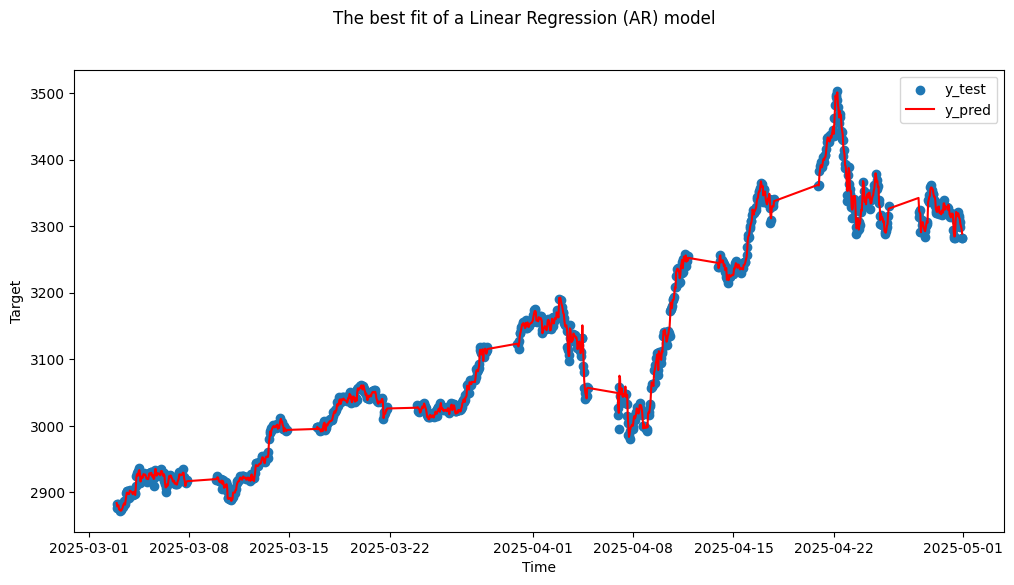

In [18]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("The best fit of a Linear Regression (AR) model")

ax.scatter(target_test.index, y_test, label='y_test')
ax.plot(target_test.index, y_pred, color='red', label='y_pred')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()

In [20]:
prediction_target, prediction_dataset = prediction_set['Close'].copy(), prediction_set.drop(columns=['Close', 'EMA20', 'RSI14', 'ATR14', 'MACD', 'MACD_Signal', 'MACD_Hist']).copy()
forecast = regressor.predict(prediction_dataset.to_numpy())

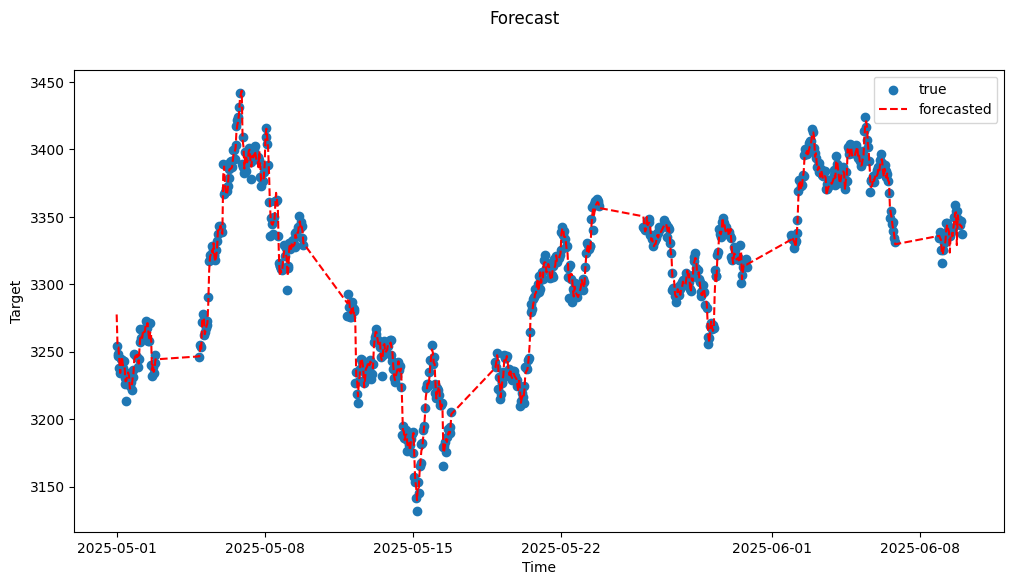

In [21]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("Forecast")

ax.scatter(prediction_target.index, prediction_target.to_numpy(), label='true')
ax.plot(prediction_target.index, forecast, color='red', linestyle='--', label='forecasted')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()

In [22]:
columns = dataset.columns
coef_names = columns
coefficients = pd.DataFrame(zip(coef_names, np.round(regressor.coef_, 3)), columns=['feature', 'value'])
coefficients.sort_values('value', ascending=False)

,feature,value
0,High,0.997
1,Low,0.000
2,Open,0.000
3,Volume,-0.000


## `High` Price Predictors

### ARIMA Model

In [54]:
train_set, test_set = dataset_us_aug[dataset_us_aug.index < '2025-06-01'].copy(), dataset_us_aug[dataset_us_aug.index >= '2025-06-01'].copy()

In [55]:
train_set = train_set.dropna()
dataset_high = train_set['High'].copy().asfreq('h').bfill().ffill()

In [14]:
arima_high = ARIMA(dataset_high, order=(2, 2, 2))
results_high = arima_high.fit()

In [54]:
results_high.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   High   No. Observations:                17220
Model:                 ARIMA(2, 2, 2)   Log Likelihood              -47481.046
Date:                Tue, 08 Jul 2025   AIC                          94972.093
Time:                        13:49:14   BIC                          95010.861
Sample:                    06-13-2023   HQIC                         94984.869
                         - 05-30-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8472      0.015    -56.540      0.000      -0.877      -0.818
ar.L2          0.1390      0.005     28.998      0.000       0.130       0.148
ma.L1         -0.0108      0.015     -0.741      0.458      -0.039       0.018
ma.L2         -0.9891      0.015    -67.747      0.000      -1.018      -0.960
sigma2        14.5400      0.040    362.054      0.000      14.461      14.619
===================================================================================
Ljung-Box (L1) (Q):                   0.22   Jarque-Bera (JB):            595339.48
Prob(Q):                              0.64   Prob(JB):                         0.00
Heteroskedasticity (H):               3.72   Skew:                             0.81
Prob(H) (two-sided):                  0.00   Kurtosis:                        31.76
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [55]:
forecast = results_high.predict(start=test_set.index[0], end=test_set.index[-1], dynamic=False)

In [65]:
true_high = test_set['High'].copy().asfreq('h').bfill().ffill()

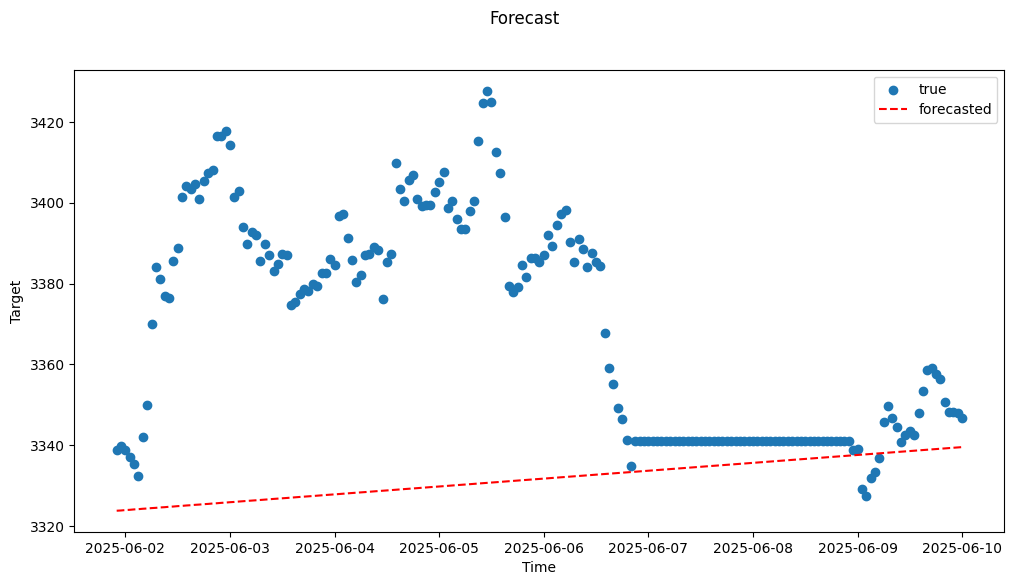

In [57]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("Forecast")

ax.scatter(true_high.index, true_high.to_numpy(), label='true')
ax.plot(true_high.index, forecast, color='red', linestyle='--', label='forecasted')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()

### LSTM

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.saving import load_model

In [4]:
params = {
    'layer1': 128,
    'layer2': 64,
    'layer3': 32,
    'dropout': 0.3,
    'learning_rate': 0.01,
    'lag': 60
}

In [56]:
last_price = dataset_high.iloc[-1]
dataset_high = dataset_high.diff().dropna()

3319.699951171875

In [57]:
model = Sequential([
    Input(shape=(params['lag'], 1)),
    LSTM(params['layer1'], return_sequences=True),
    Dropout(params['dropout']),
    LSTM(params['layer2']),
    Dropout(params['dropout']),
    Dense(params['layer3'], activation='relu'),
    Dense(1)
])
model.compile(optimizer=Adam(learning_rate=params['learning_rate']), loss='mse')

In [58]:
def _prepare_data(df: pd.DataFrame, lag: int):
    data = df.copy()

    target_data = data.copy()

    X = sliding_window_view(data.to_numpy(), window_shape=lag, axis=0)
    X = X[:-1]
    y = target_data[lag:].to_numpy()

    return X, y

In [59]:
train_size = 0.7

In [60]:
train_size = int(len(dataset_high) * train_size)
train_set, val_set = dataset_high.iloc[:train_size], dataset_high.iloc[train_size:]

X_train, y_train = _prepare_data(train_set, lag=params['lag'])
X_val, y_val = _prepare_data(val_set, lag=params['lag'])

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[EarlyStopping(patience=10, restore_best_weights=True)],
    verbose=1
)

Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - loss: 9.3025 - val_loss: 26.6361
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 131ms/step - loss: 9.1647 - val_loss: 26.5721
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - loss: 9.4636 - val_loss: 26.4496
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - loss: 9.5621 - val_loss: 26.3664
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 25s 133ms/step - loss: 9.3616 - val_loss: 26.5275


In [61]:
def predict(dataset, last_price, date_range: pd.DatetimeIndex) -> pd.Series:

    history_df = dataset.copy()

    for idx, date in enumerate(date_range):
        x_ = history_df.iloc[-params['lag']:].to_numpy().reshape(1, params['lag'], -1)
        y_ = model.predict(x_, verbose=0)[0]

        history_df = pd.concat([history_df, pd.Series(y_, index=[date])])

    y_pred = history_df.loc[date_range[0]:date_range[-1]]
    predicted_price = last_price + np.cumsum(y_pred)

    return predicted_price

In [62]:
y_pred = predict(dataset_high, last_price, date_range=true_high.index)

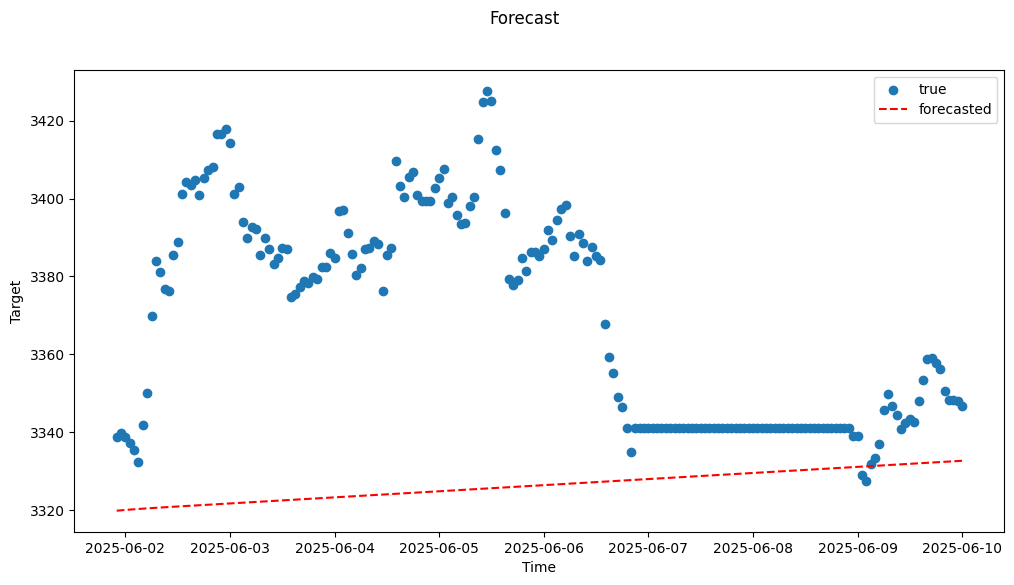

In [66]:
fig, ax = plt.subplots(nrows=1, figsize=(12, 6))
fig.suptitle("Forecast")

ax.scatter(true_high.index, true_high.to_numpy(), label='true')
ax.plot(true_high.index, y_pred, color='red', linestyle='--', label='forecasted')
ax.set_xlabel("Time")
ax.set_ylabel('Target')
ax.legend()